Project name
overview
the dataset


## Import the neccary libraries

In [269]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from collections import Counter
import glob
import os
import re

import warnings
warnings.filterwarnings('ignore')

In [270]:
# For cleaner plots
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

In [271]:
files = [file for file in os.listdir('../data/raw/')]
data = pd.DataFrame()
for file in files:
    all_csvs = pd.read_csv('../data/raw/' + file)
    data = pd.concat([all_csvs, data])   
# data.to_csv('../data/processed/uk_pay_gap_2017-25_.csv', index=False)

## Read the dataset

In [272]:
df = pd.read_csv('../data/processed/uk_pay_gap_2017-25_.csv')

In [273]:
df.head()

,EmployerName,EmployerId,Address,PostCode,CompanyNumber,SicCodes,DiffMeanHourlyPercent,DiffMedianHourlyPercent,DiffMeanBonusPercent,DiffMedianBonusPercent,MaleBonusPercent,FemaleBonusPercent,MaleLowerQuartile,FemaleLowerQuartile,MaleLowerMiddleQuartile,FemaleLowerMiddleQuartile,MaleUpperMiddleQuartile,FemaleUpperMiddleQuartile,MaleTopQuartile,FemaleTopQuartile,CompanyLinkToGPGInfo,ResponsiblePerson,EmployerSize,CurrentName,SubmittedAfterTheDeadline,DueDate,DateSubmitted
0,1ST HOME CARE LTD.,17484,"Suite 1, Ground Floor Academy House, 1346 Shet...",G32 9AT,SC272838,"86900,\n88100",-0.72,0.06,NaN,NaN,0.0,0.0,14.71,85.29,5.89,94.11,11.77,88.23,14.71,85.29,NaN,David Sargent (CEO),Less than 250,1ST HOME CARE LTD.,False,2025/04/05 00:00:00,2024/07/01 15:43:41
1,6 POINT 6 LIMITED,22664,"30 Fenchurch Street, London, England, EC3M 3BD",EC3M 3BD,07946687,62020,22.00,24.00,15.00,33.0,92.0,87.0,58.00,42.00,69.00,31.00,82.00,18.00,89.00,11.00,NaN,Janet Coulthurst (Chief of Staff),250 to 499,6 POINT 6 LIMITED,False,2025/04/05 00:00:00,2024/12/16 11:12:30
2,725 LIMITED,17859,"48 High Street, Gravesend, Kent, England, DA11...",DA11 0AY,05983359,"41100,\n78200",2.50,3.78,NaN,NaN,0.0,0.0,31.00,69.00,31.00,69.00,31.00,69.00,51.00,49.00,NaN,DIPESH LIMBU (ACCOUNTANT),250 to 499,725 LIMITED,False,2025/04/05 00:00:00,2024/12/16 15:06:04
3,A J RAYSON LIMITED,23378,"Bartle House, Oxford Court, Manchester, Englan...",M2 3WQ,14187704,70229,1.37,5.24,NaN,NaN,0.0,0.0,9.00,91.00,21.00,79.00,22.00,78.00,35.80,64.20,NaN,Abigail Rayson (Director),250 to 499,A J RAYSON LIMITED,False,2025/04/05 00:00:00,2024/05/20 10:03:35
4,A P P WHOLESALE LIMITED,21477,"Unit 1 Radford Industrial Estate, Goodhall Str...",NW10 6UA,06552800,46740,-4.26,15.13,-33.39,-20.0,88.0,95.0,91.94,8.06,86.89,13.11,76.67,23.33,84.17,15.83,https://www.lordsgrouptradingplc.co.uk/about-u...,Anne Prince (Group HR Director),Less than 250,A P P WHOLESALE LIMITED,False,2025/04/05 00:00:00,2024/09/17 13:59:33


## Data Exploration

In [274]:
df.shape

(72810, 27)

In [275]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72810 entries, 0 to 72809
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   EmployerName               72810 non-null  object 
 1   EmployerId                 72810 non-null  int64  
 2   Address                    72714 non-null  object 
 3   PostCode                   72522 non-null  object 
 4   CompanyNumber              63108 non-null  object 
 5   SicCodes                   68080 non-null  object 
 6   DiffMeanHourlyPercent      72810 non-null  float64
 7   DiffMedianHourlyPercent    72810 non-null  float64
 8   DiffMeanBonusPercent       58000 non-null  float64
 9   DiffMedianBonusPercent     57998 non-null  float64
 10  MaleBonusPercent           72810 non-null  float64
 11  FemaleBonusPercent         72810 non-null  float64
 12  MaleLowerQuartile          72411 non-null  float64
 13  FemaleLowerQuartile        72411 non-null  flo

- Noticed missing values

In [276]:
df.isnull().sum()

EmployerName                     0
EmployerId                       0
Address                         96
PostCode                       288
CompanyNumber                 9702
SicCodes                      4730
DiffMeanHourlyPercent            0
DiffMedianHourlyPercent          0
DiffMeanBonusPercent         14810
DiffMedianBonusPercent       14812
MaleBonusPercent                 0
FemaleBonusPercent               0
MaleLowerQuartile              399
FemaleLowerQuartile            399
MaleLowerMiddleQuartile        399
FemaleLowerMiddleQuartile      399
MaleUpperMiddleQuartile        399
FemaleUpperMiddleQuartile      399
MaleTopQuartile                399
FemaleTopQuartile              399
CompanyLinkToGPGInfo         25860
ResponsiblePerson            12659
EmployerSize                     0
CurrentName                      0
SubmittedAfterTheDeadline        0
DueDate                          0
DateSubmitted                    0
dtype: int64

In [277]:
# Missing value count and percentage
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Column', 'MissingValues']
missing_df['MissingPercentage'] = 100 * missing_df['MissingValues'] / len(df)
missing_df = missing_df.sort_values(by='MissingPercentage', ascending=False)

# Display missing value summary
missing_df

,Column,MissingValues,MissingPercentage
20,CompanyLinkToGPGInfo,25860,35.517099
9,DiffMedianBonusPercent,14812,20.343359
8,DiffMeanBonusPercent,14810,20.340613
21,ResponsiblePerson,12659,17.386348
4,CompanyNumber,9702,13.325093
5,SicCodes,4730,6.496360
14,MaleLowerMiddleQuartile,399,0.548002
13,FemaleLowerQuartile,399,0.548002
12,MaleLowerQuartile,399,0.548002
16,MaleUpperMiddleQuartile,399,0.548002


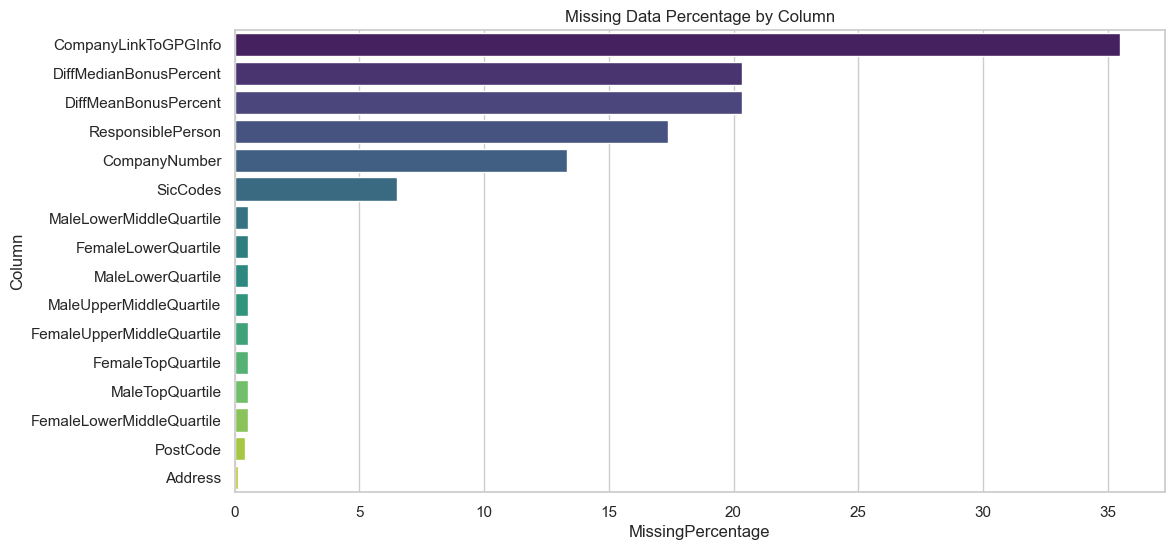

In [278]:
# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df[missing_df.MissingPercentage > 0], 
            x='MissingPercentage', 
            y='Column', 
            palette='viridis')
plt.title('Missing Data Percentage by Column')
plt.show()

In [279]:
df[df['CompanyLinkToGPGInfo'].isna()].head(3)

,EmployerName,EmployerId,Address,PostCode,CompanyNumber,SicCodes,DiffMeanHourlyPercent,DiffMedianHourlyPercent,DiffMeanBonusPercent,DiffMedianBonusPercent,MaleBonusPercent,FemaleBonusPercent,MaleLowerQuartile,FemaleLowerQuartile,MaleLowerMiddleQuartile,FemaleLowerMiddleQuartile,MaleUpperMiddleQuartile,FemaleUpperMiddleQuartile,MaleTopQuartile,FemaleTopQuartile,CompanyLinkToGPGInfo,ResponsiblePerson,EmployerSize,CurrentName,SubmittedAfterTheDeadline,DueDate,DateSubmitted
0,1ST HOME CARE LTD.,17484,"Suite 1, Ground Floor Academy House, 1346 Shet...",G32 9AT,SC272838,"86900,\n88100",-0.72,0.06,NaN,NaN,0.0,0.0,14.71,85.29,5.89,94.11,11.77,88.23,14.71,85.29,NaN,David Sargent (CEO),Less than 250,1ST HOME CARE LTD.,False,2025/04/05 00:00:00,2024/07/01 15:43:41
1,6 POINT 6 LIMITED,22664,"30 Fenchurch Street, London, England, EC3M 3BD",EC3M 3BD,07946687,62020,22.00,24.00,15.0,33.0,92.0,87.0,58.00,42.00,69.00,31.00,82.00,18.00,89.00,11.00,NaN,Janet Coulthurst (Chief of Staff),250 to 499,6 POINT 6 LIMITED,False,2025/04/05 00:00:00,2024/12/16 11:12:30
2,725 LIMITED,17859,"48 High Street, Gravesend, Kent, England, DA11...",DA11 0AY,05983359,"41100,\n78200",2.50,3.78,NaN,NaN,0.0,0.0,31.00,69.00,31.00,69.00,31.00,69.00,51.00,49.00,NaN,DIPESH LIMBU (ACCOUNTANT),250 to 499,725 LIMITED,False,2025/04/05 00:00:00,2024/12/16 15:06:04


## Univarte Analysis

### Numercal Columns

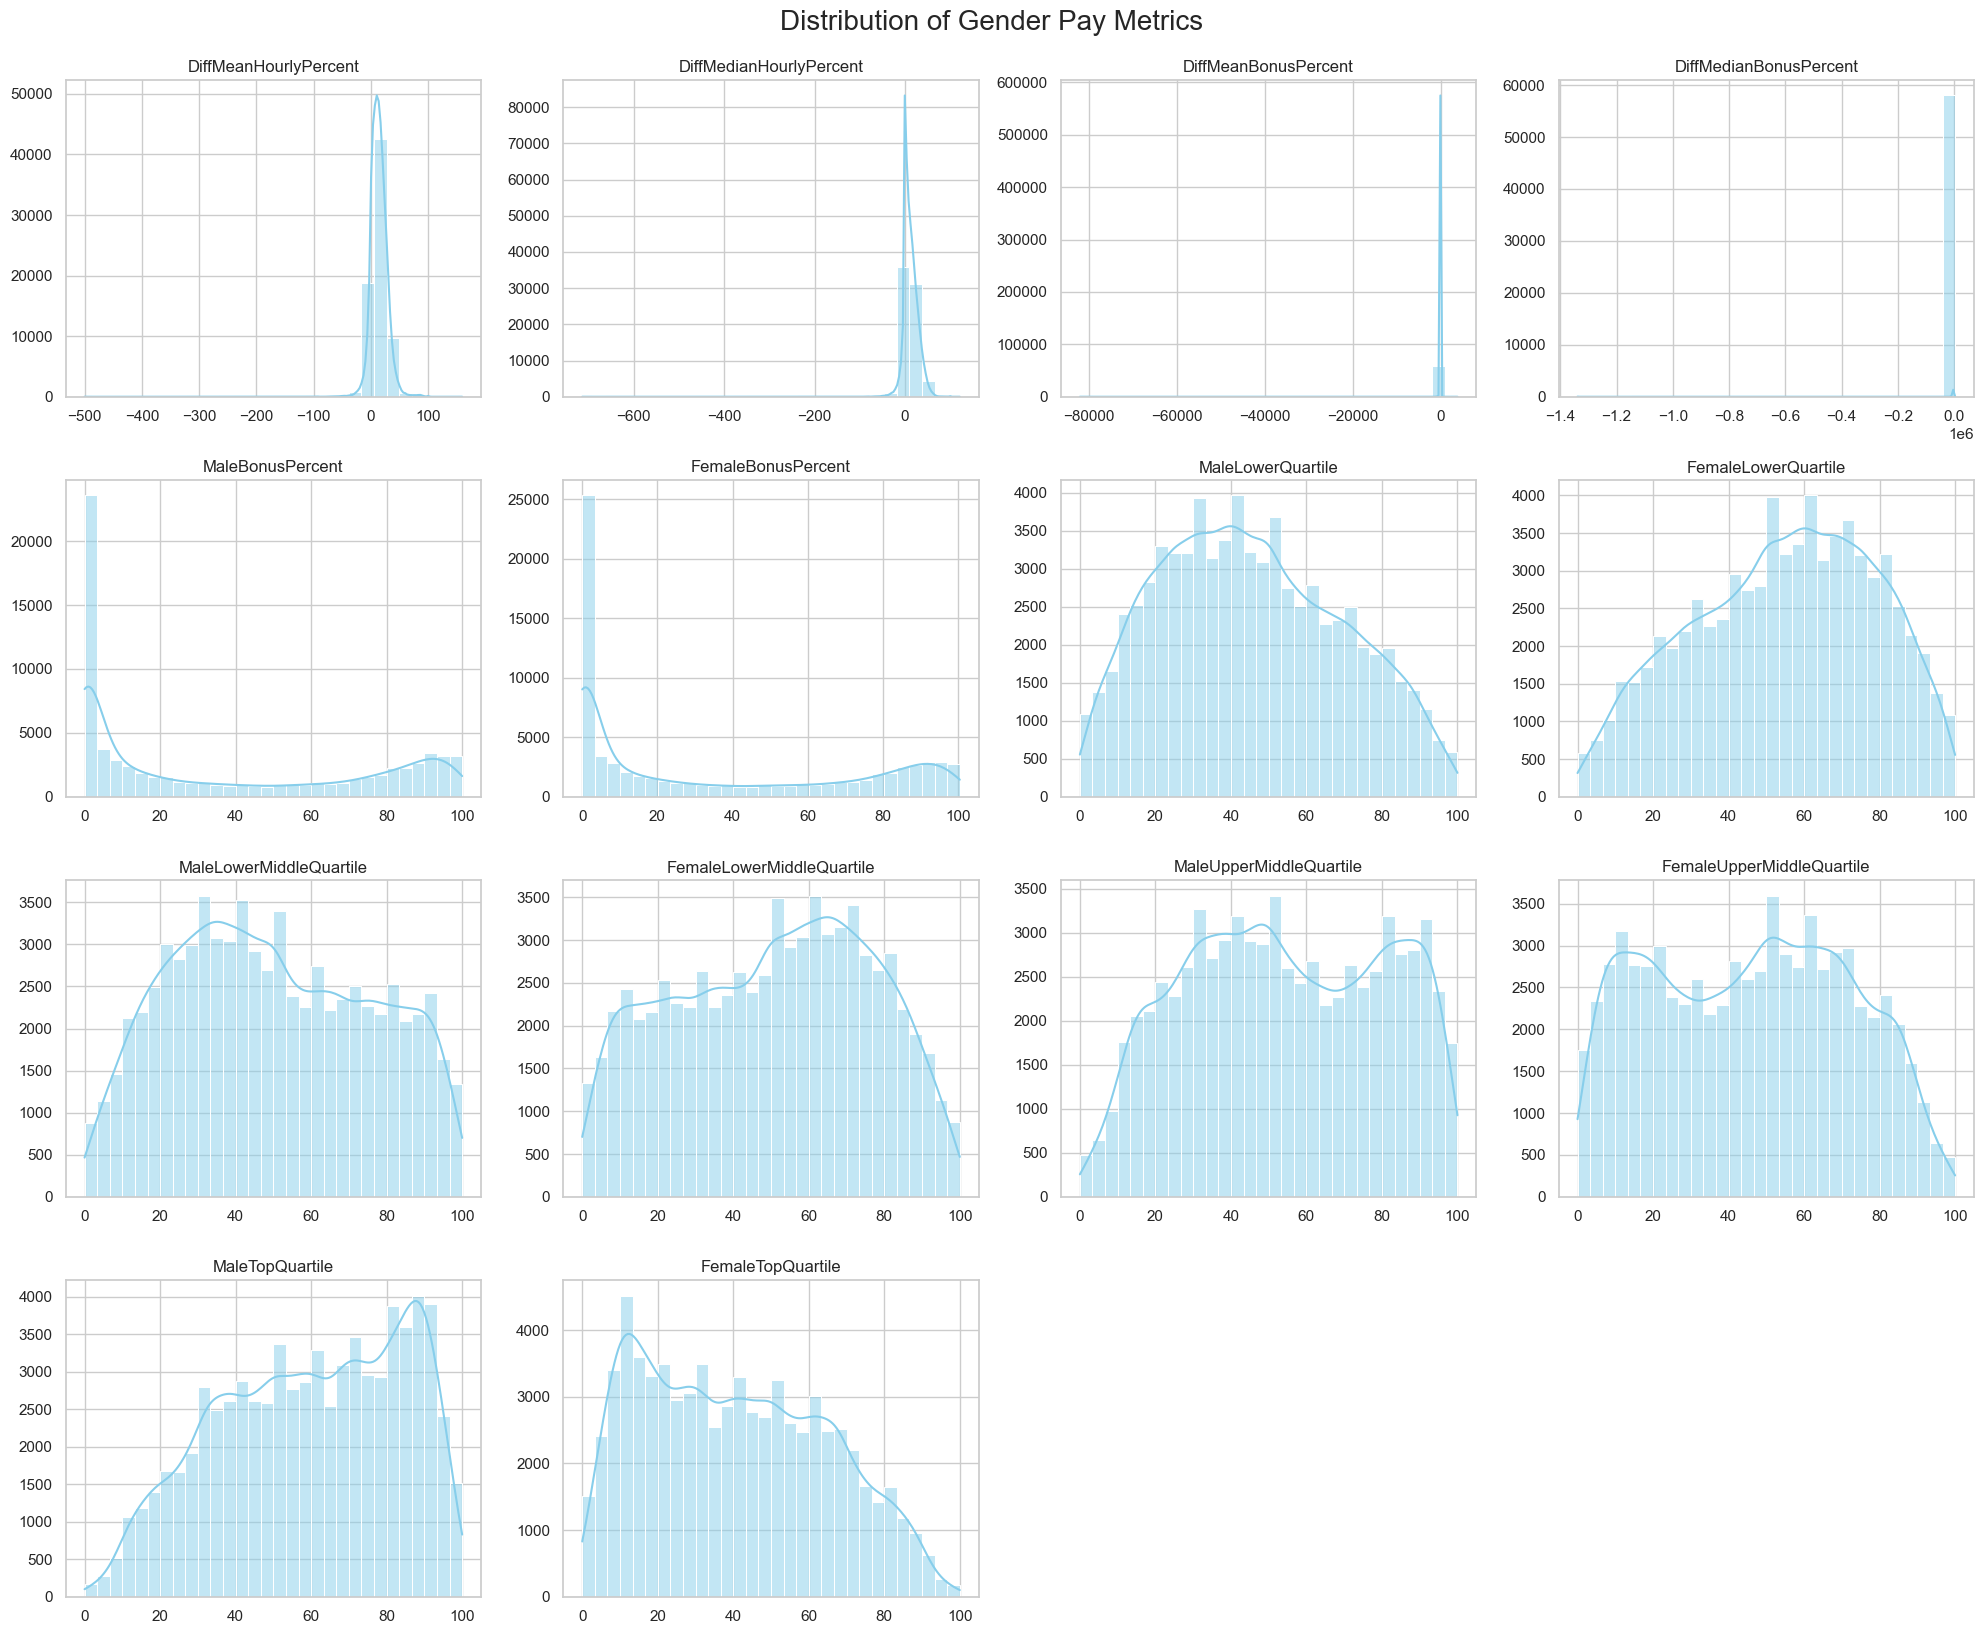

In [280]:
# List of the gender pay-related columns
columns_to_plot = [
    'DiffMeanHourlyPercent', 'DiffMedianHourlyPercent',
    'DiffMeanBonusPercent', 'DiffMedianBonusPercent',
    'MaleBonusPercent', 'FemaleBonusPercent',
    'MaleLowerQuartile', 'FemaleLowerQuartile',
    'MaleLowerMiddleQuartile', 'FemaleLowerMiddleQuartile',
    'MaleUpperMiddleQuartile', 'FemaleUpperMiddleQuartile',
    'MaleTopQuartile', 'FemaleTopQuartile'
]

# Set up subplots: 4 rows x 4 columns
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

# Plot each column
for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any extra subplots (if less than 16 total)
for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Distribution of Gender Pay Metrics", fontsize=20, y=1.02)
plt.show()

## Biavariate Analysis

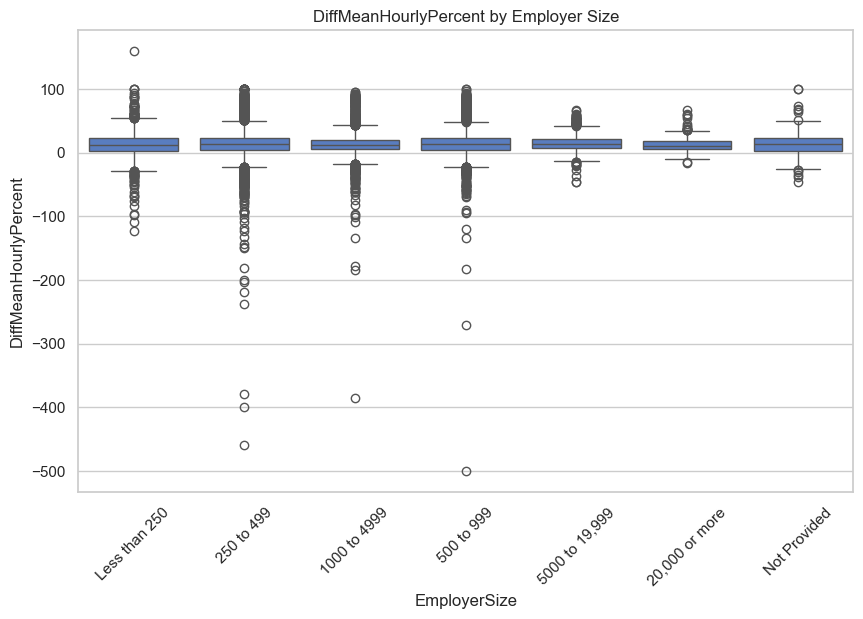

In [281]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='EmployerSize', y='DiffMeanHourlyPercent', data=df)
plt.title('DiffMeanHourlyPercent by Employer Size')
plt.xticks(rotation=45)
plt.show()

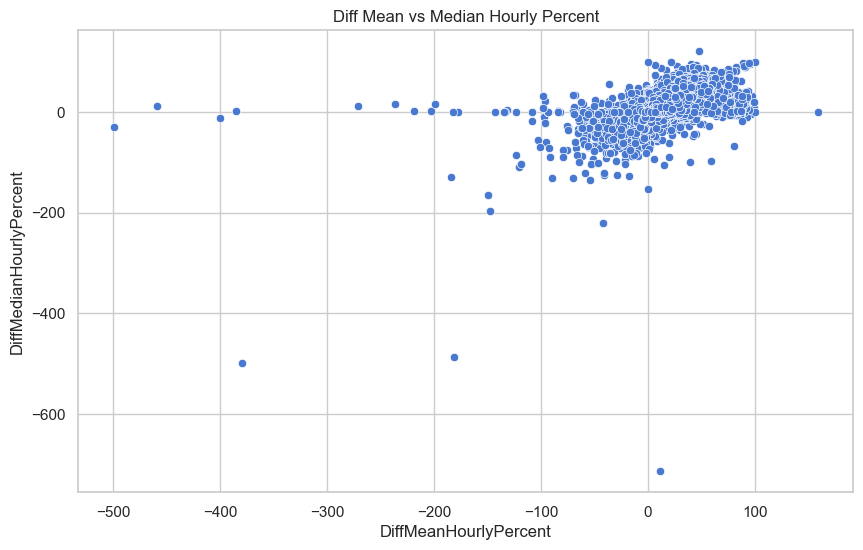

In [282]:
sns.scatterplot(data=df, x='DiffMeanHourlyPercent', y='DiffMedianHourlyPercent')
plt.title('Diff Mean vs Median Hourly Percent')
plt.show()

## Multivariate Analysis

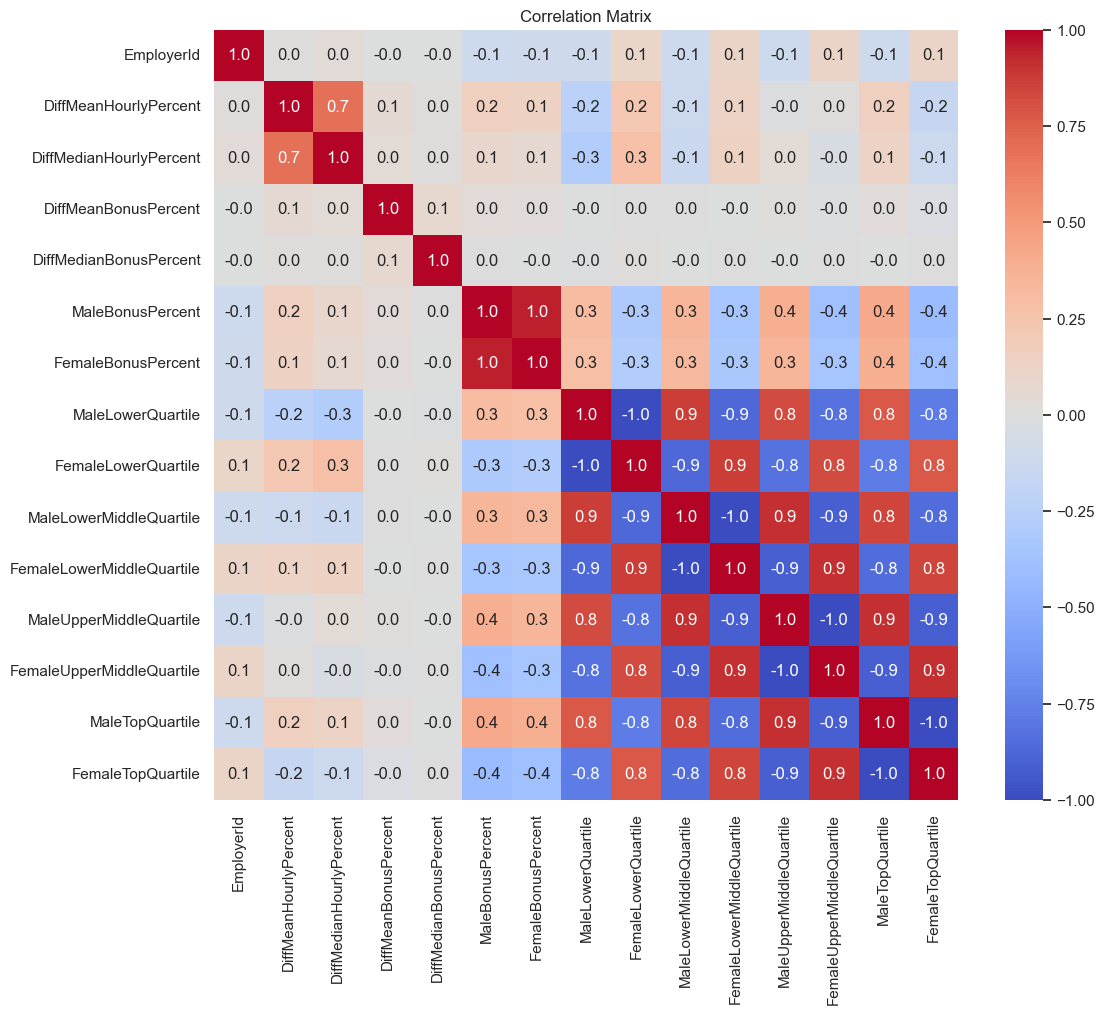

In [283]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

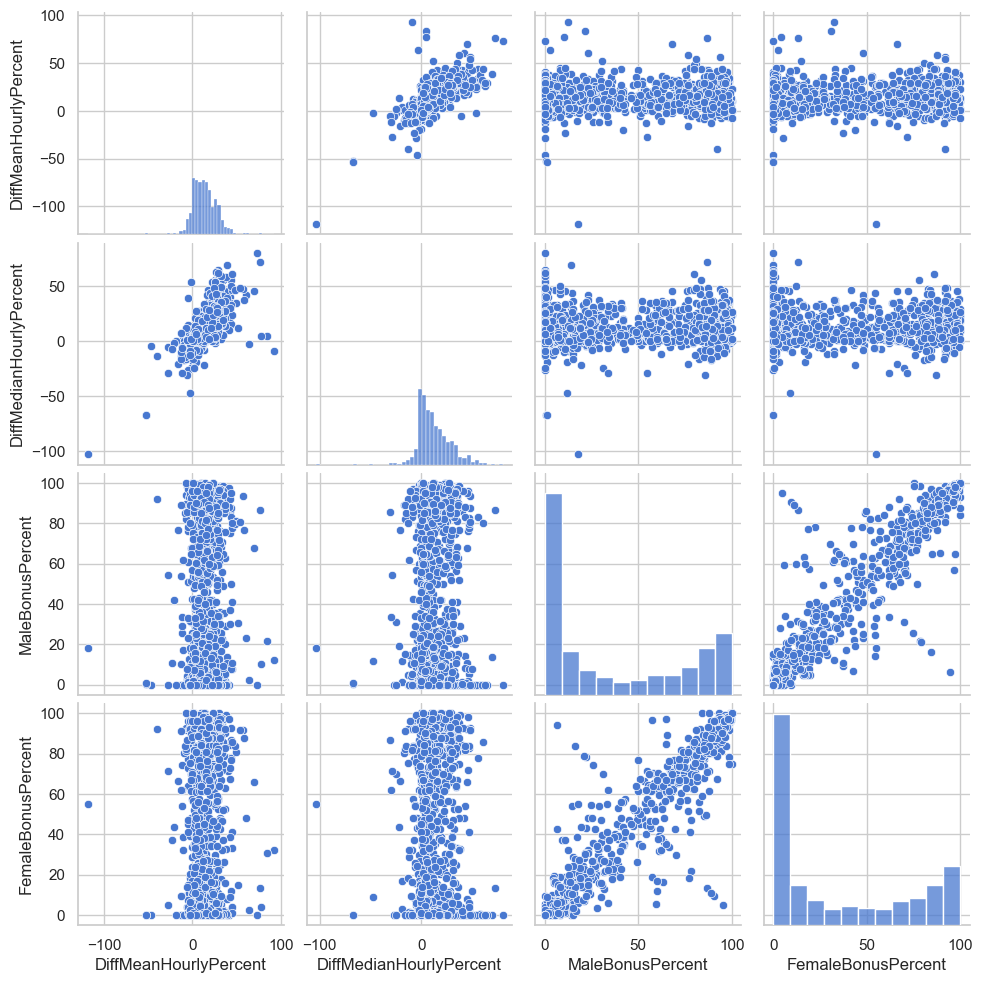

In [284]:
sample_df = df.sample(1000, random_state=42)  # speed it up
sns.pairplot(sample_df[['DiffMeanHourlyPercent', 'DiffMedianHourlyPercent', 
                        'MaleBonusPercent', 'FemaleBonusPercent']])
plt.show()

## Data Cleaning

In [285]:
df_clean = df.copy()

In [286]:
# Fill common missing values (examples below)
df_clean['CompanyNumber'].fillna('Unknown', inplace=True)

In [287]:
# Fill bonus percentage with median (numerical imputation)
df_clean['DiffMeanBonusPercent'].fillna(df_clean['DiffMeanBonusPercent'].median(), inplace=True)
df_clean['DiffMedianBonusPercent'].fillna(df_clean['DiffMedianBonusPercent'].median(), inplace=True)

In [288]:
# Fill bonus percentage with median (numerical imputation)
df_clean['DiffMeanBonusPercent'].fillna(df_clean['DiffMeanBonusPercent'].median(), inplace=True)
df_clean['DiffMedianBonusPercent'].fillna(df_clean['DiffMedianBonusPercent'].median(), inplace=True)

In [289]:
# Fill quartiles with median
quartile_cols = [col for col in df_clean.columns if 'Quartile' in col]
df_clean[quartile_cols] = df_clean[quartile_cols].fillna(df_clean[quartile_cols].median())

In [290]:
# Drop high-missing/less relevant columns if necessary
df_clean.drop(columns=['CompanyLinkToGPGInfo'], inplace=True)

In [291]:
# Convert date columns
df_clean['DateSubmitted'] = pd.to_datetime(df_clean['DateSubmitted'], errors='coerce')
df_clean['DueDate'] = pd.to_datetime(df_clean['DueDate'], errors='coerce')

# Outlier Detection

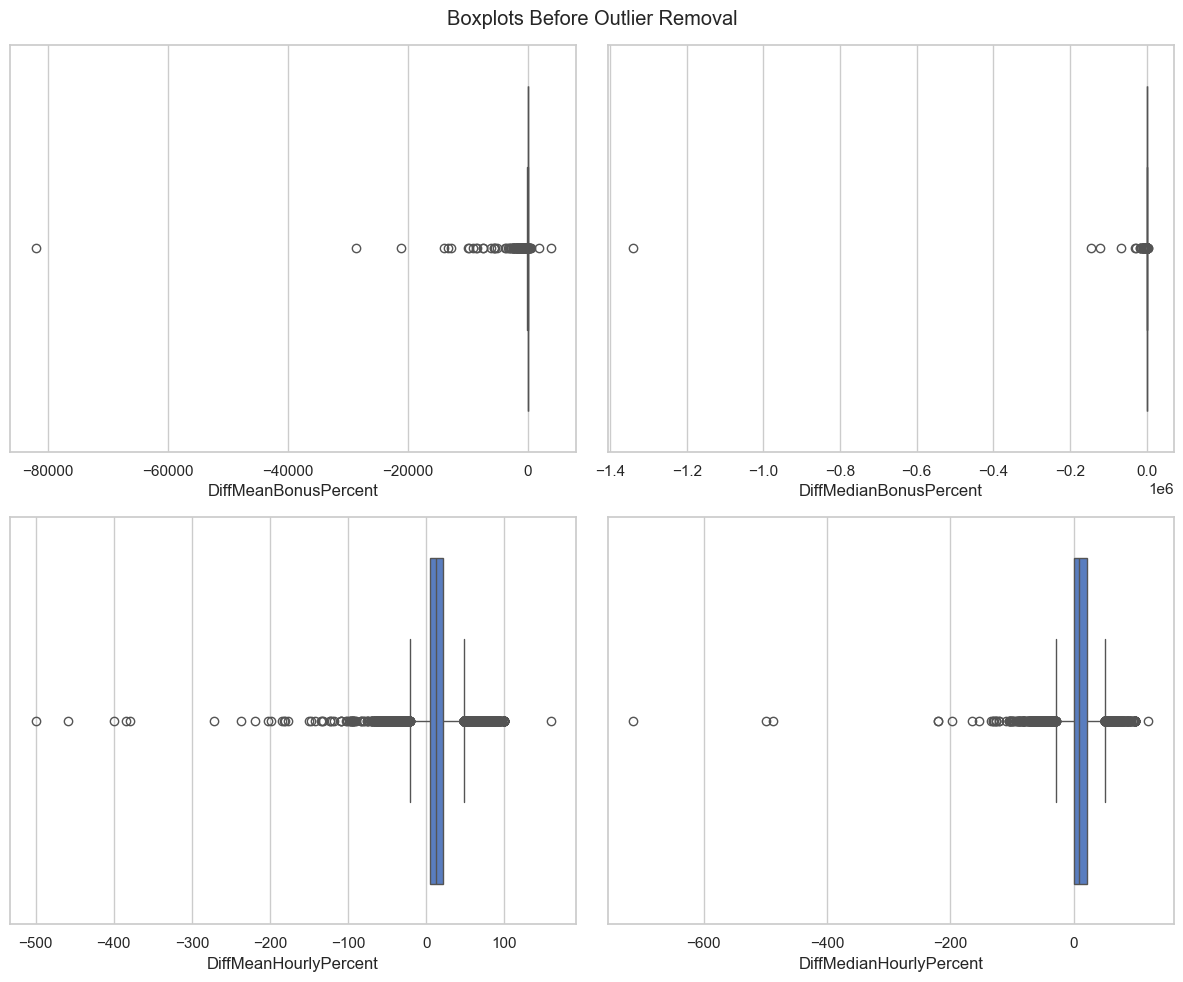

In [292]:
# 1. Box plots before outlier removal
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(ax=axes[0, 0], x=df['DiffMeanBonusPercent'])
sns.boxplot(ax=axes[0, 1], x=df['DiffMedianBonusPercent'])
sns.boxplot(ax=axes[1, 0], x=df['DiffMeanHourlyPercent'])
sns.boxplot(ax=axes[1, 1], x=df['DiffMedianHourlyPercent'])
fig.suptitle('Boxplots Before Outlier Removal')
plt.tight_layout()

# Show before plots
plt.show()

In [293]:
# Example using IQR method for multiple columns
for col in ['DiffMeanBonusPercent', 'DiffMedianBonusPercent', 
            'DiffMeanHourlyPercent', 'DiffMedianHourlyPercent']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5 * IQR) & (df_clean[col] <= Q3 + 1.5 * IQR)]

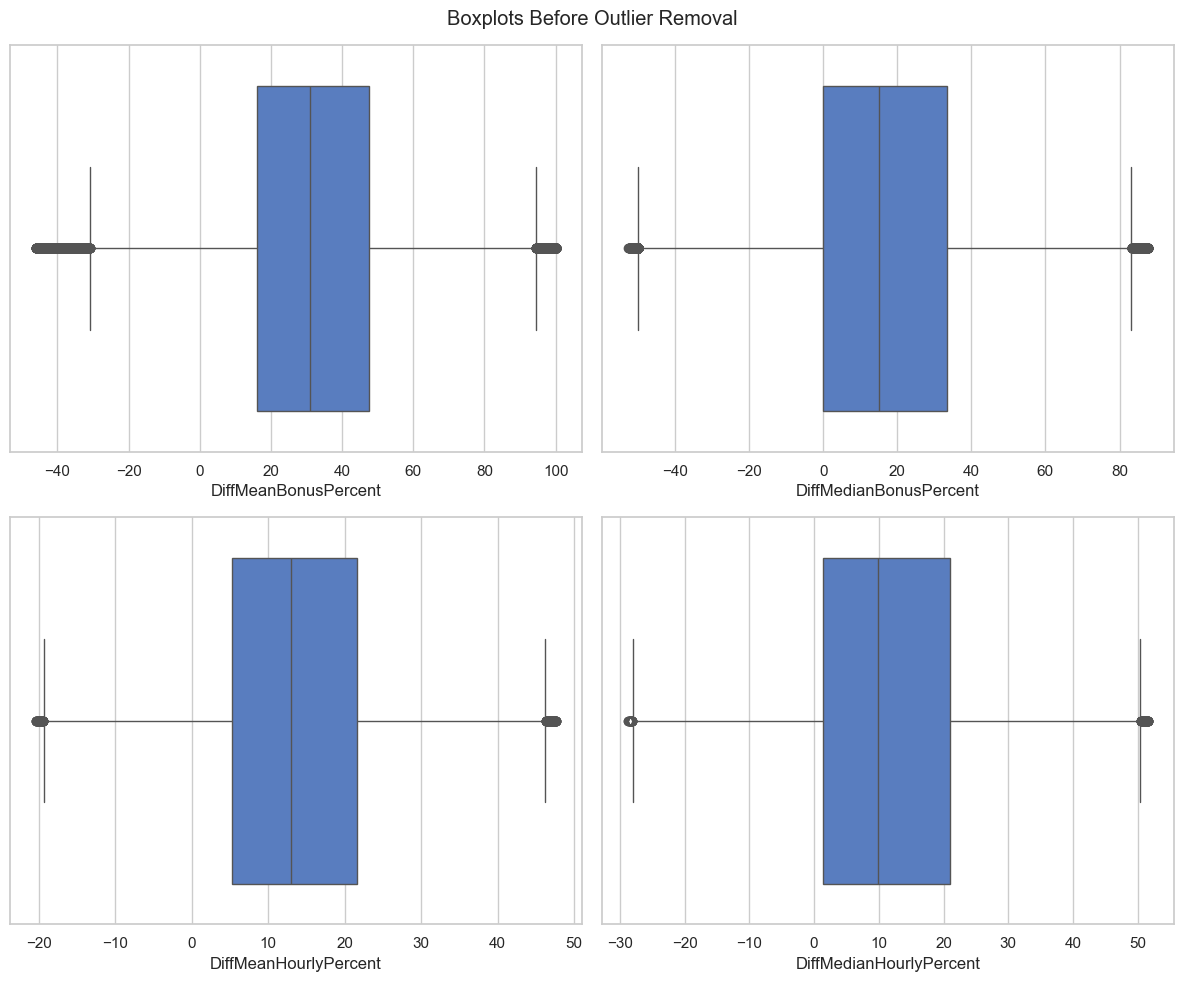

In [294]:
# 1. Box plots before outlier removal
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(ax=axes[0, 0], x=df_clean['DiffMeanBonusPercent'])
sns.boxplot(ax=axes[0, 1], x=df_clean['DiffMedianBonusPercent'])
sns.boxplot(ax=axes[1, 0], x=df_clean['DiffMeanHourlyPercent'])
sns.boxplot(ax=axes[1, 1], x=df_clean['DiffMedianHourlyPercent'])
fig.suptitle('Boxplots Before Outlier Removal')
plt.tight_layout()

# Show before plots
plt.show()

# Analysis

#### Create new feature called region for the analysis

In [295]:
uk_regions = [
    'North East', 'North West', 'Yorkshire and the Humber', 'East Midlands',
    'West Midlands', 'East of England', 'London', 'South East', 'South West',
    'Wales', 'Scotland', 'Northern Ireland'
]

def extract_region(address, regions):
    if isinstance(address, str):
        for region in regions:
            if region.lower() in address.lower():
                return region
    return None
df_clean['region'] = df_clean['Address'].apply(lambda x: extract_region(x, uk_regions))

## **Average Gender Pay Gap Over Time**

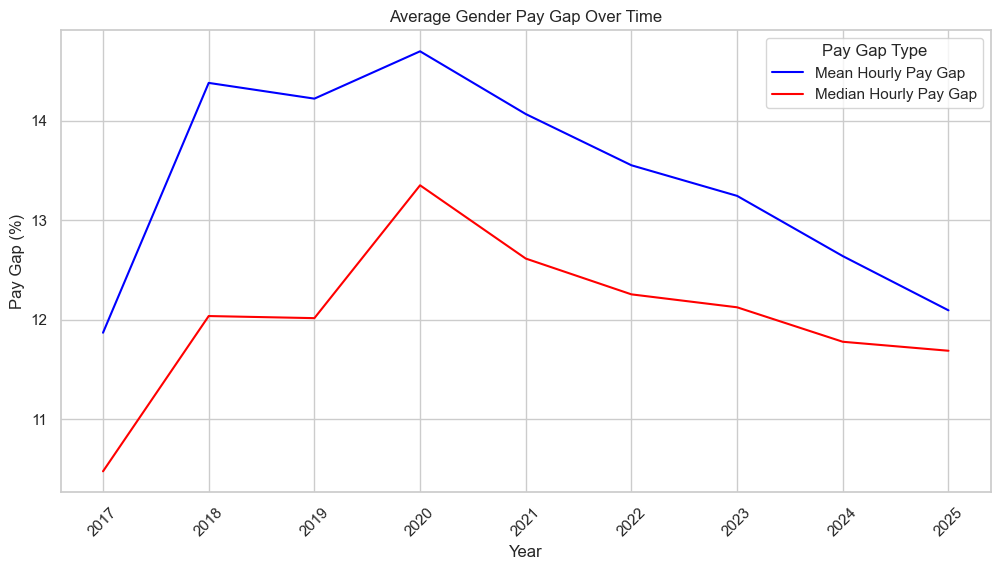

In [296]:
# Extract the year from the DateSubmitted column
df_clean['year'] = pd.to_datetime(df_clean['DateSubmitted']).dt.year

# Group by year and calculate the mean of hourly and median pay gaps
df_avg_gap_yearly = df_clean.groupby('year')[['DiffMeanHourlyPercent', 'DiffMedianHourlyPercent']].mean().reset_index()

# Plot the line chart to show the trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_avg_gap_yearly, x='year', y='DiffMeanHourlyPercent', label='Mean Hourly Pay Gap', color='blue')
sns.lineplot(data=df_avg_gap_yearly, x='year', y='DiffMedianHourlyPercent', label='Median Hourly Pay Gap', color='red')

plt.title('Average Gender Pay Gap Over Time')
plt.xlabel('Year')
plt.ylabel('Pay Gap (%)')
plt.legend(title='Pay Gap Type')
plt.xticks(rotation=45)
plt.show()

## Side-by-Side Comparisons for Hourly vs. Bonus Gaps

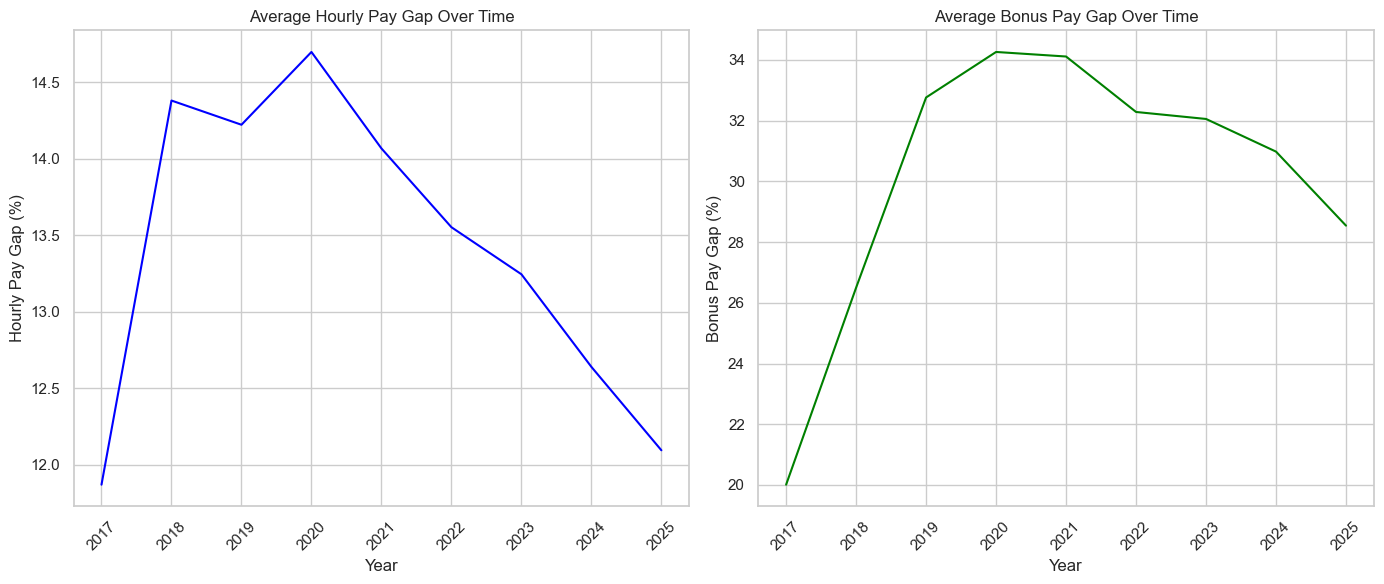

In [297]:
# Group by year and calculate the mean of hourly and bonus pay gaps
df_avg_gap_yearly_bonus = df_clean.groupby('year')[['DiffMeanHourlyPercent', 'DiffMeanBonusPercent']].mean().reset_index()

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot the first chart for Hourly Pay Gap
sns.lineplot(data=df_avg_gap_yearly_bonus, x='year', y='DiffMeanHourlyPercent', ax=ax[0], color='blue')
ax[0].set_title('Average Hourly Pay Gap Over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Hourly Pay Gap (%)')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

# Plot the second chart for Bonus Pay Gap
sns.lineplot(data=df_avg_gap_yearly_bonus, x='year', y='DiffMeanBonusPercent', ax=ax[1], color='green')
ax[1].set_title('Average Bonus Pay Gap Over Time')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Bonus Pay Gap (%)')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart: Employer Size vs DiffMeanHourlyPercent (Aggregated Mean)

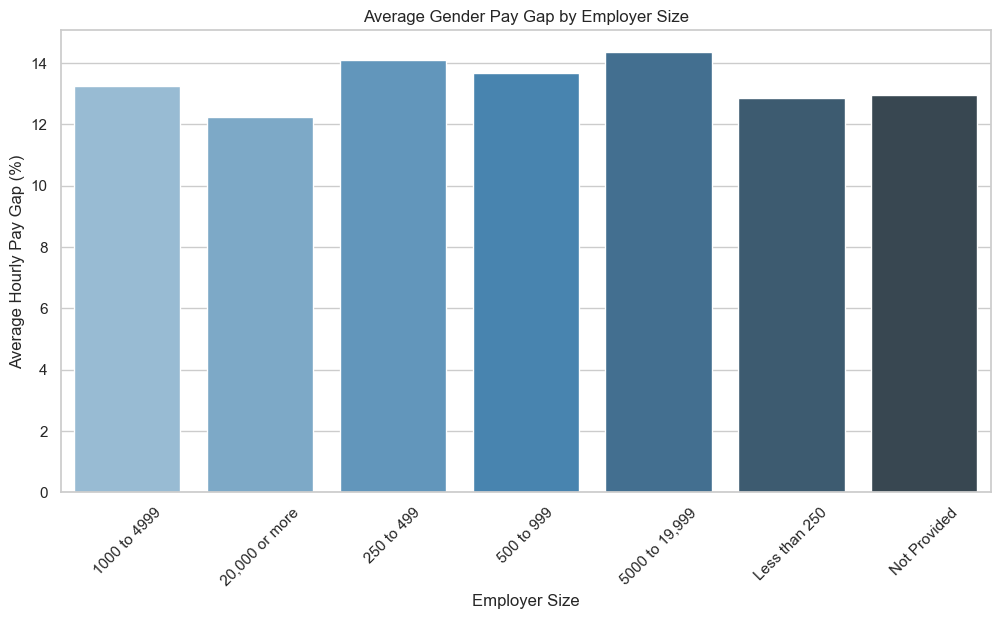

In [298]:
# Group by EmployerSize and calculate the mean DiffMeanHourlyPercent for each size category
df_avg_gap_size = df_clean.groupby('EmployerSize')['DiffMeanHourlyPercent'].mean().reset_index()

# Plot the bar chart to visualize the average hourly pay gap by employer size
plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg_gap_size, x='EmployerSize', y='DiffMeanHourlyPercent', palette='Blues_d')
plt.title('Average Gender Pay Gap by Employer Size')
plt.xlabel('Employer Size')
plt.ylabel('Average Hourly Pay Gap (%)')
plt.xticks(rotation=45)
plt.show()

## Boxplots by Employer Size

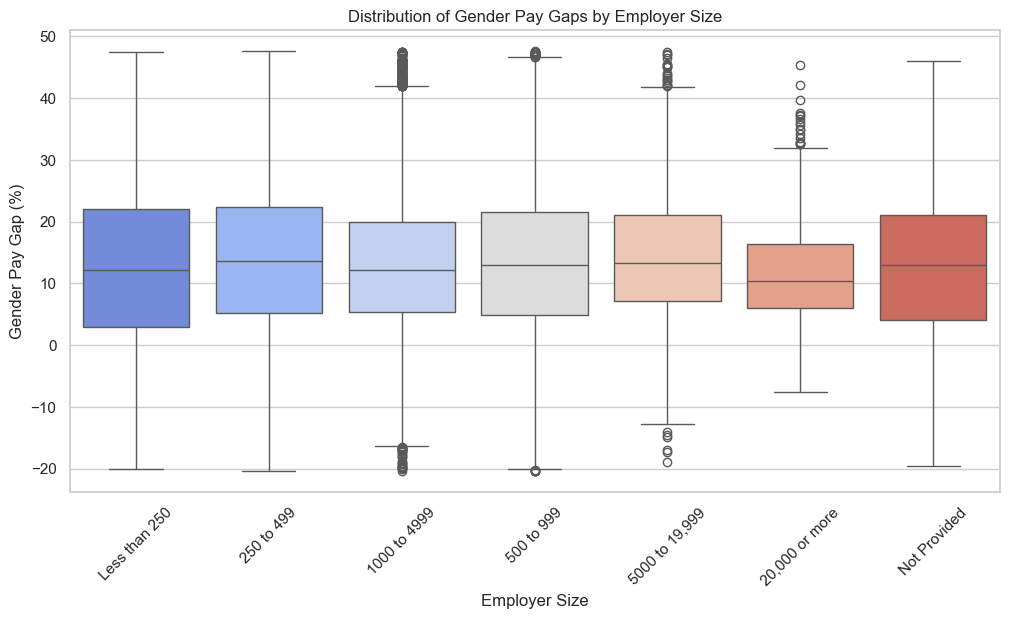

In [299]:
# Plotting the boxplot to show the distribution of pay gaps by employer size
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='EmployerSize', y='DiffMeanHourlyPercent', palette='coolwarm')
plt.title('Distribution of Gender Pay Gaps by Employer Size')
plt.xlabel('Employer Size')
plt.ylabel('Gender Pay Gap (%)')
plt.xticks(rotation=45)
plt.show()

## Visualize the Gender Pay Gap by Sector

In [300]:
def map_sic_to_sector(sic):
    """
    Map a SIC code (as a string) to a broad UK business sector.
    This example uses the first two digits of the numeric portion.
    """
    # Remove any non-digit characters
    code = ''.join(filter(str.isdigit, sic))
    if not code:
        return "Unknown"
    try:
        # Use the first two digits for classification
        prefix = int(code[:2])
    except Exception:
        return "Unknown"
    
    # Simplified rules (adjust as needed)
    if 1 <= prefix <= 3:
        return "Agriculture, Forestry & Fishing"
    elif 10 <= prefix <= 33:
        return "Manufacturing"
    elif 35 <= prefix <= 39:
        return "Utilities"
    elif 41 <= prefix <= 43:
        return "Construction"
    elif 45 <= prefix <= 47:
        return "Wholesale & Retail Trade"
    elif 49 <= prefix <= 53:
        return "Transportation & Storage"
    elif prefix == 55:
        return "Accommodation & Food Services"
    elif 58 <= prefix <= 63:
        return "Information & Communication"
    elif 64 <= prefix <= 66:
        return "Financial & Insurance"
    elif prefix == 68:
        return "Real Estate"
    elif 69 <= prefix <= 75:
        return "Professional, Scientific & Technical Activities"
    elif 77 <= prefix <= 82:
        return "Administrative & Support Services"
    elif prefix == 84:
        return "Public Administration & Defence"
    elif prefix == 85:
        return "Education"
    elif 86 <= prefix <= 88:
        return "Human Health & Social Work"
    elif prefix == 90:
        return "Arts, Entertainment & Recreation"
    elif 91 <= prefix <= 93:
        return "Other Service Activities"
    elif prefix == 94:
        return "Households as Employers"
    elif prefix == 95:
        return "Extraterrestrial Organizations"
    else:
        return "Other"

In [301]:
def process_sic_codes(sic_str):
    """
    Given a string of one or more SIC codes (separated by commas and/or newline),
    split the string, map each individual code to a sector using map_sic_to_sector,
    and return a comma-separated string of unique sector names.
    """
    if not isinstance(sic_str, str):
        return "Unknown"
    # Split the string on commas and newline characters
    codes = re.split(r'[,\\n]+', sic_str)
    codes = [code.strip() for code in codes if code.strip()]
    # Map each code to a business sector
    sectors = [map_sic_to_sector(code) for code in codes]
    # Remove duplicate sectors
    unique_sectors = sorted(set(sectors))
    return ", ".join(unique_sectors)

# Assume the SIC code column is named "SICCode"
df['Business Sector'] = df['SicCodes'].apply(process_sic_codes)

In [302]:
sector_counter = Counter()
for sectors in df['Business Sector']:
    # Split by comma and strip whitespace
    for sector in sectors.split(","):
        sector = sector.strip()
        if sector:
            sector_counter[sector] += 1

# Convert to a DataFrame for plotting
sector_counts = pd.DataFrame(sector_counter.items(), columns=['Business Sector', 'Count'])
sector_counts = sector_counts.sort_values(by='Count', ascending=False)

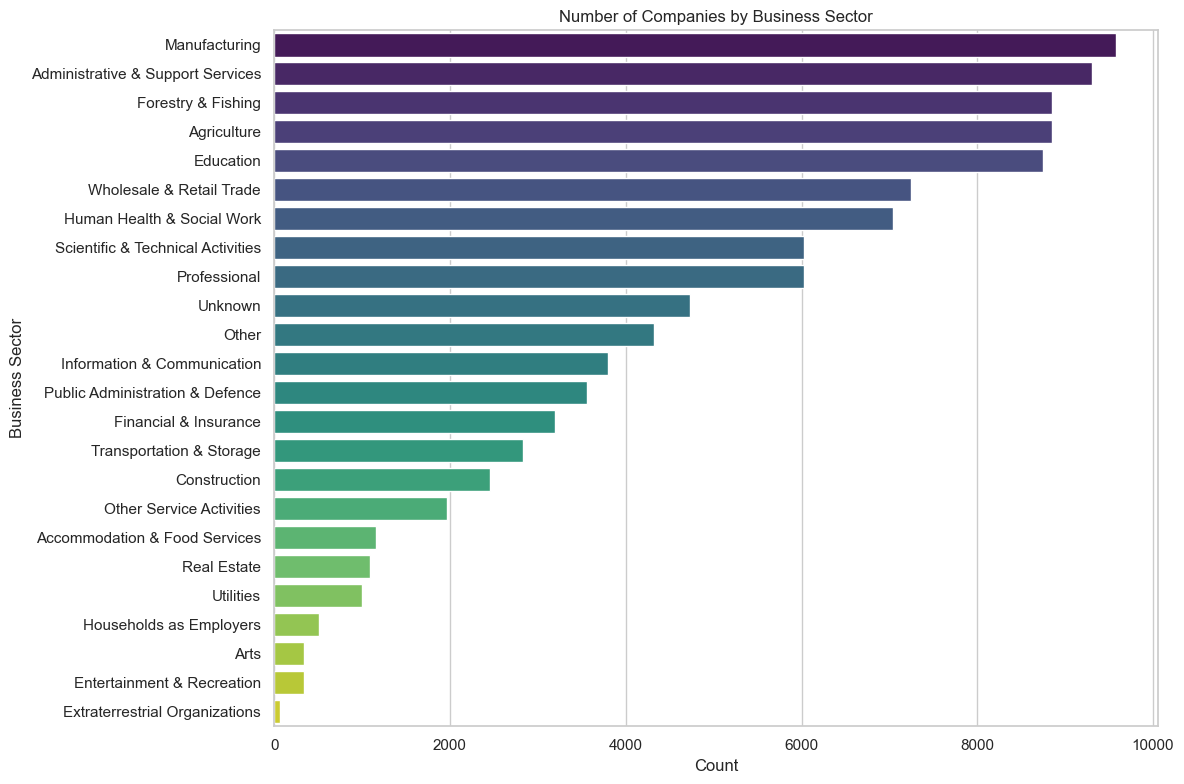

In [303]:
plt.figure(figsize=(12, 8))
sns.barplot(data=sector_counts, x='Count', y='Business Sector', palette="viridis")
plt.title("Number of Companies by Business Sector")
plt.xlabel("Count")
plt.ylabel("Business Sector")
plt.tight_layout()
plt.show()

## Average Gender Pay Gap by Region

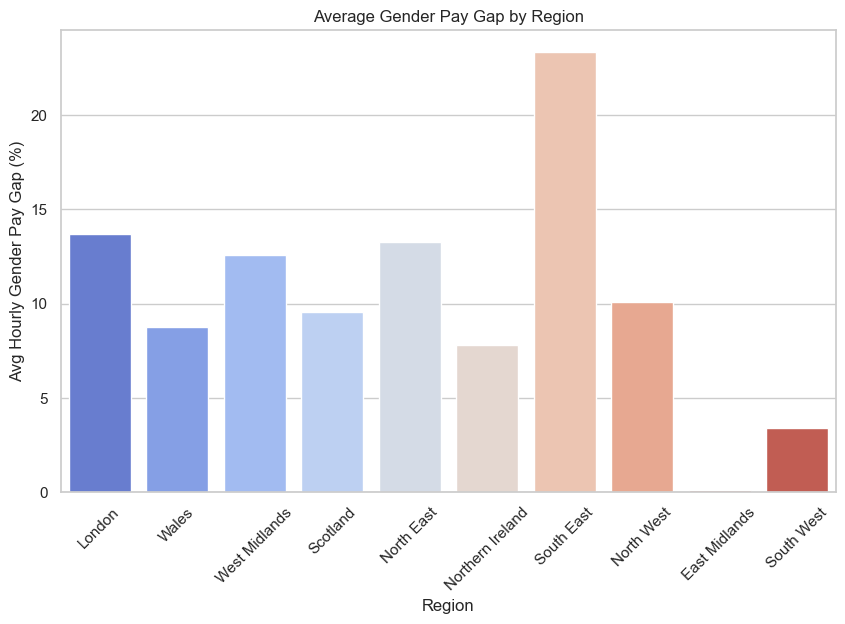

In [304]:
plt.figure(figsize=(10,6))

df_region_sorted = df_clean.sort_values("DiffMedianHourlyPercent", ascending=False)
# Plot using the sorted DataFrame
sns.barplot(
    data=df_region_sorted,
    x="region",
    y="DiffMedianHourlyPercent",
    palette="coolwarm",
    ci=None  # Remove error bars
)

plt.title("Average Gender Pay Gap by Region")
plt.ylabel("Avg Hourly Gender Pay Gap (%)")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.show()


   PostCode         region            city
0  EC2R 7HJ        England  City of London
1   LS1 4DL        England            None
2   SE1 2AF        England          London
3   SR3 3XP  Tyne and Wear      Sunderland
4   E14 5HU        England            None


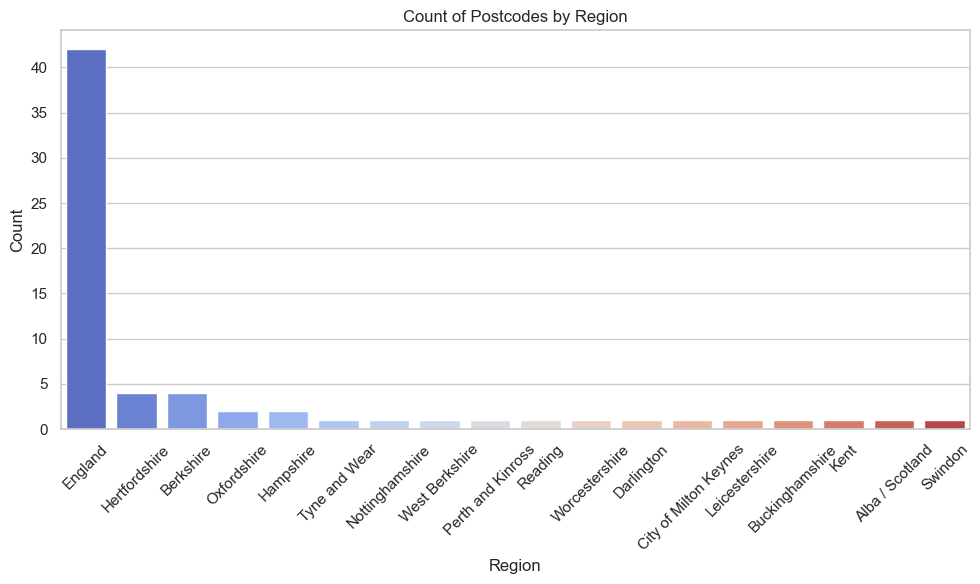

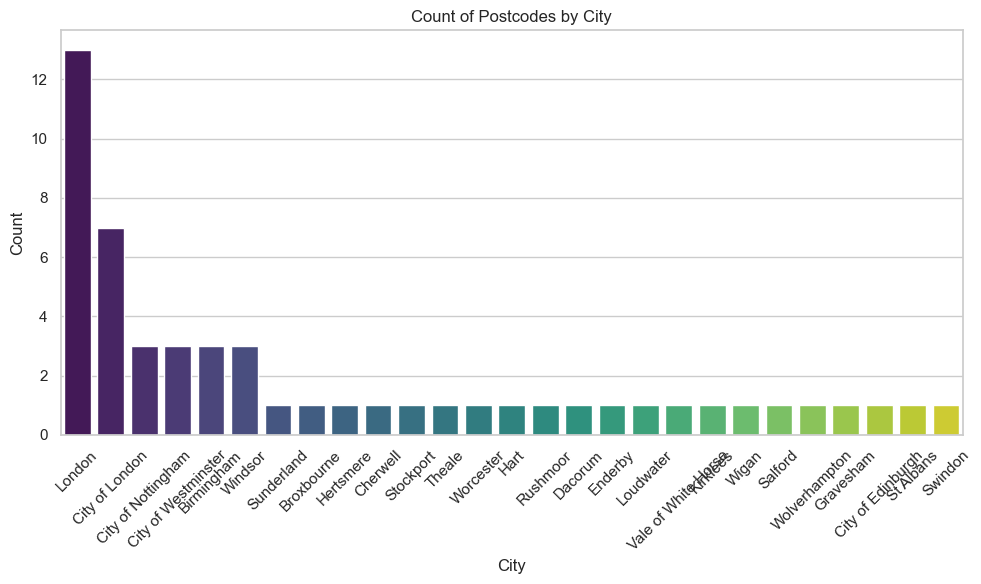

In [305]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.geocoders import Nominatim

# -------------------------------------
# 1. Define Your List of Postcodes
# (Replace the list below with your actual data if needed)
postcodes = [
    "EC2R 7HJ", "LS1 4DL", "SE1 2AF", "SR3 3XP", "E14 5HU", "NG7 2SZ",
    "SE1 9SG", "W2 6BD", "B4 6AT", "N12 9QD", "NG15 0DR", "SK9 1BU",
    "SK1 3SW", "EC2N 4BQ", "W14 8UD", "RG1 3JH", "IP3 9SJ", "EN11 9BX",
    "EC2M 4AG", "B3 3AX", "WA14 5XS", "EC3V 0BG", "SE1 0SW", "EH3 8BP",
    "W1U 1QX", "EN6 1AG", "EC4N 6EU", "EC2A 2AP", "W1K 4QY", "W2 1AF",
    "W12 7FR", "LS1 5AB", "OX16 0TB", "N1C 4AG", "EC2V 7BG", "RG7 4SA",
    "NE12 8BU", "EC3M 3BY", "EC4M 7WS", "SL4 1EG", "E20 1JN", "PH1 3AQ",
    "WR1 3ZQ", "PE11 3YR", "TW7 5QD", "RG27 9XA", "SL4 5GD", "DL3 6AH",
    "WF2 8EE", "MK10 0BN", "NG2 1LU", "SL4 1RS", "B24 9FD", "EC2Y 5EB",
    "GU11 1PZ", "HP2 7AH", "LE19 4AT", "NW10 7BW", "W1T 4EZ", "EC4R 9AT",
    "E14 5AQ", "RG2 6AD", "NG2 1AE", "HP11 1JL", "OX14 4SE", "WC1X 0DW",
    "E4 9JG", "HD2 1GZ", "B30 2HP", "WN3 5BB", "M27 8LN", "WV14 0UJ",
    "DA11 0AY", "EC2A 4BX", "NW10 6UA", "EH28 8PH", "AL1 1JB", "TW9 2PR",
    "SN2 1UH"
]

# Create a DataFrame from the list
df_postcodes = pd.DataFrame({"PostCode": postcodes})

# -------------------------------------
# 2. Define a function to get region and city via geocoding
# -------------------------------------
geolocator = Nominatim(user_agent="uk_postcode_mapper")

def get_region_city(postcode):
    """
    Look up the postcode using Nominatim and extract region and city.
    Returns a tuple: (region, city)
    """
    try:
        location = geolocator.geocode(postcode, country_codes="gb", addressdetails=True)
        if location is None:
            return None, None
        address = location.raw.get("address", {})
        # Try extracting city from several possible keys
        city = address.get("city", address.get("town", address.get("village", None)))
        # For the region, often the 'county' key is used in the UK
        region = address.get("county", address.get("state", None))
        return region, city
    except Exception as e:
        # In case of any error, return None for both
        return None, None

# -------------------------------------
# 3. Apply the function to each postcode with a delay
# -------------------------------------
results = []
for pc in df_postcodes["PostCode"]:
    region, city = get_region_city(pc)
    results.append({"PostCode": pc, "region": region, "city": city})
    time.sleep(1)  # Wait 1 second between requests to avoid rate limiting

df_results = pd.DataFrame(results)
print(df_results.head())

# -------------------------------------
# 4. Visualize: Bar plot of count by region
# -------------------------------------
# Count how many postcodes fall into each region
region_counts = df_results["region"].value_counts().reset_index()
region_counts.columns = ["region", "count"]

plt.figure(figsize=(10,6))
sns.barplot(data=region_counts, x="region", y="count", palette="coolwarm")
plt.title("Count of Postcodes by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------------
# 5. Visualize: Bar plot of count by city (optional)
# -------------------------------------
city_counts = df_results["city"].value_counts().reset_index()
city_counts.columns = ["city", "count"]

plt.figure(figsize=(10,6))
sns.barplot(data=city_counts, x="city", y="count", palette="viridis")
plt.title("Count of Postcodes by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Stacked Bar Chart: Female vs Male Top Quartile per Year

<Figure size 1200x600 with 0 Axes>

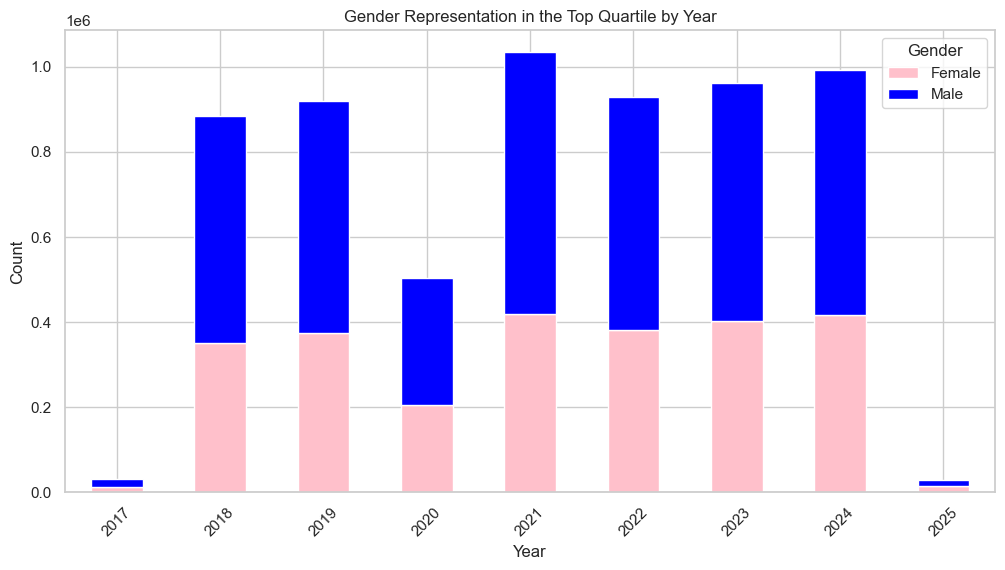

In [306]:
# Group by year and sum the FemaleTopQuartile and MaleTopQuartile for each year
df_top_quartile = df_clean.groupby('year')[['FemaleTopQuartile', 'MaleTopQuartile']].sum().reset_index()

# Plot the stacked bar chart to compare Female and Male representation in the Top Quartile
plt.figure(figsize=(12, 6))
df_top_quartile.set_index('year')[['FemaleTopQuartile', 'MaleTopQuartile']].plot(kind='bar', stacked=True, color=['pink', 'blue'], figsize=(12, 6))

plt.title('Gender Representation in the Top Quartile by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.show()

## Quartile Difference Over Time (Line or Area Chart)

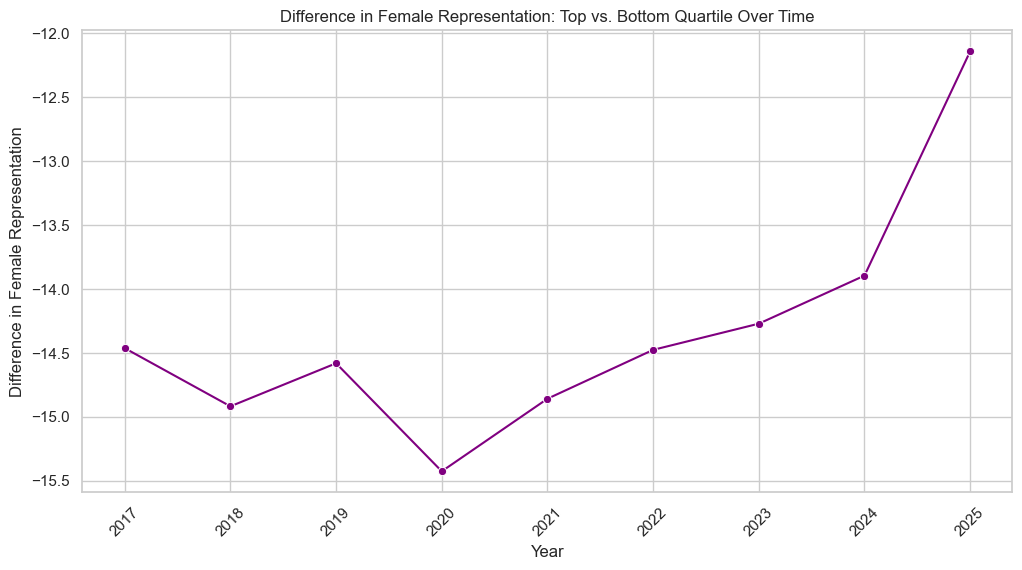

In [307]:
# Calculate the difference between FemaleTopQuartile and FemaleLowerQuartile for each year
df_clean['FemaleTopMinusBottomQuartile'] = df_clean['FemaleTopQuartile'] - df_clean['FemaleLowerQuartile']

# Group by year and calculate the mean of the difference for each year
df_quartile_diff = df_clean.groupby('year')['FemaleTopMinusBottomQuartile'].mean().reset_index()

# Plot the line chart to show the difference in female representation between top and bottom quartiles over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_quartile_diff, x='year', y='FemaleTopMinusBottomQuartile', color='purple', marker='o')

plt.title('Difference in Female Representation: Top vs. Bottom Quartile Over Time')
plt.xlabel('Year')
plt.ylabel('Difference in Female Representation')
plt.xticks(rotation=45)
plt.show()

## Boxplot: DiffMeanBonusPercent vs. DiffMeanHourlyPercent

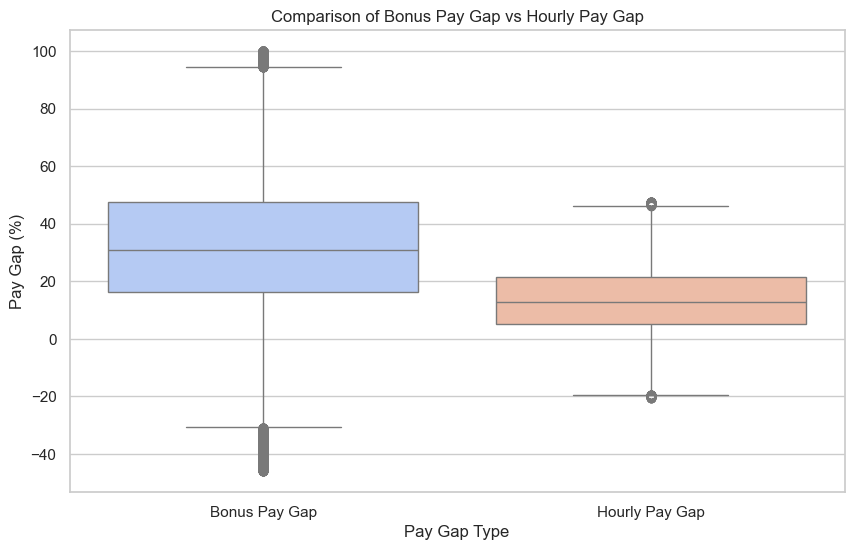

In [308]:
# Plot the boxplot to compare DiffMeanBonusPercent vs DiffMeanHourlyPercent
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[['DiffMeanBonusPercent', 'DiffMeanHourlyPercent']], palette='coolwarm')
plt.title('Comparison of Bonus Pay Gap vs Hourly Pay Gap')
plt.xlabel('Pay Gap Type')
plt.ylabel('Pay Gap (%)')
plt.xticks([0, 1], ['Bonus Pay Gap', 'Hourly Pay Gap'])
plt.show()

## Bar Chart: Male vs Female Bonus Percent by Year or Sector

<Figure size 1200x600 with 0 Axes>

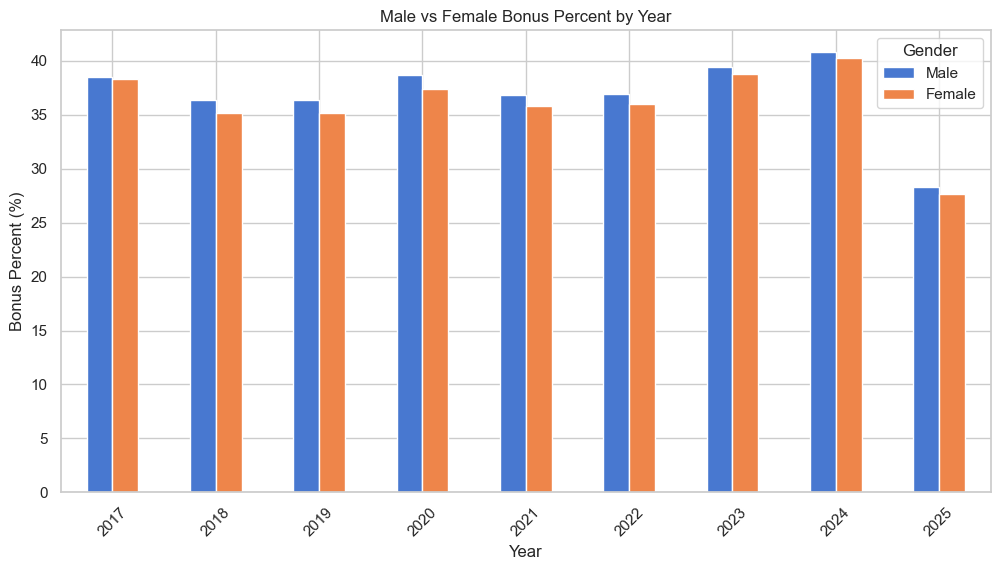

In [309]:
# Group by year and calculate the mean MaleBonusPercent and FemaleBonusPercent
df_bonus_by_year = df_clean.groupby('year')[['MaleBonusPercent', 'FemaleBonusPercent']].mean().reset_index()

# Plot the bar chart to compare Male and Female Bonus Percent by year
plt.figure(figsize=(12, 6))
df_bonus_by_year.set_index('year')[['MaleBonusPercent', 'FemaleBonusPercent']].plot(kind='bar', figsize=(12, 6))
plt.title('Male vs Female Bonus Percent by Year')
plt.xlabel('Year')
plt.ylabel('Bonus Percent (%)')
plt.xticks(rotation=45)
plt.legend(title='Gender', labels=['Male', 'Female'])
plt.show()

## Pie Chart: Percentage of Companies That Submit Late

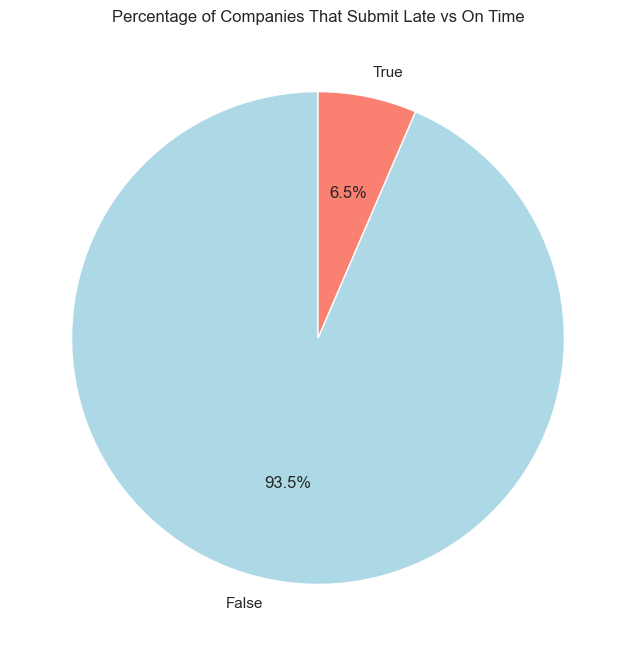

In [310]:
# Calculate the number of late and on-time submissions
submission_status = df_clean['SubmittedAfterTheDeadline'].value_counts()

# Plot the pie chart for late vs on-time submissions
plt.figure(figsize=(8, 8))
submission_status.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'salmon'], startangle=90, cmap='coolwarm')
plt.title('Percentage of Companies That Submit Late vs On Time')
plt.ylabel('')
plt.show()

## Boxplot or Violin Plot: DiffMeanHourlyPercent by

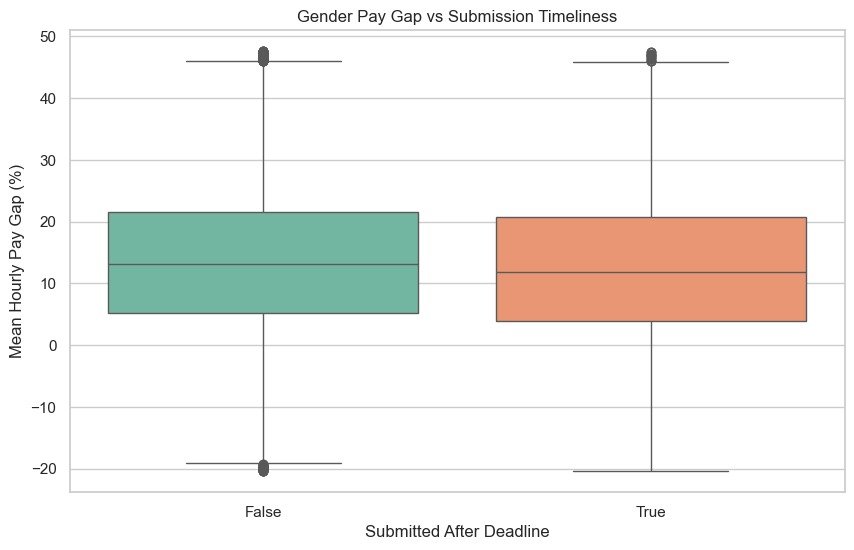

In [311]:
# Plot a boxplot to compare DiffMeanHourlyPercent for companies that submitted late vs on time
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='SubmittedAfterTheDeadline', y='DiffMeanHourlyPercent', palette='Set2')
plt.title('Gender Pay Gap vs Submission Timeliness')
plt.xlabel('Submitted After Deadline')
plt.ylabel('Mean Hourly Pay Gap (%)')
plt.show()

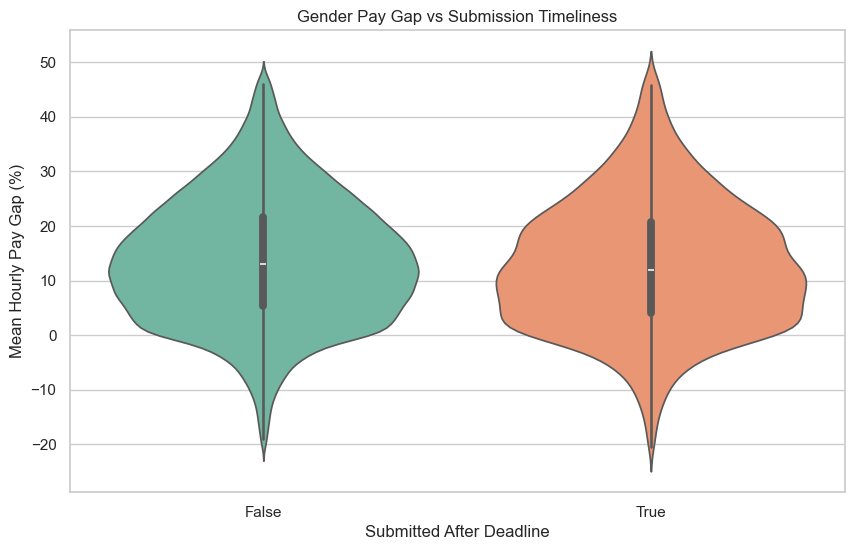

In [312]:
# Plot a violin plot to compare DiffMeanHourlyPercent for companies that submitted late vs on time
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='SubmittedAfterTheDeadline', y='DiffMeanHourlyPercent', palette='Set2')
plt.title('Gender Pay Gap vs Submission Timeliness')
plt.xlabel('Submitted After Deadline')
plt.ylabel('Mean Hourly Pay Gap (%)')
plt.show()

## Regression Plot or Trend Line Projection

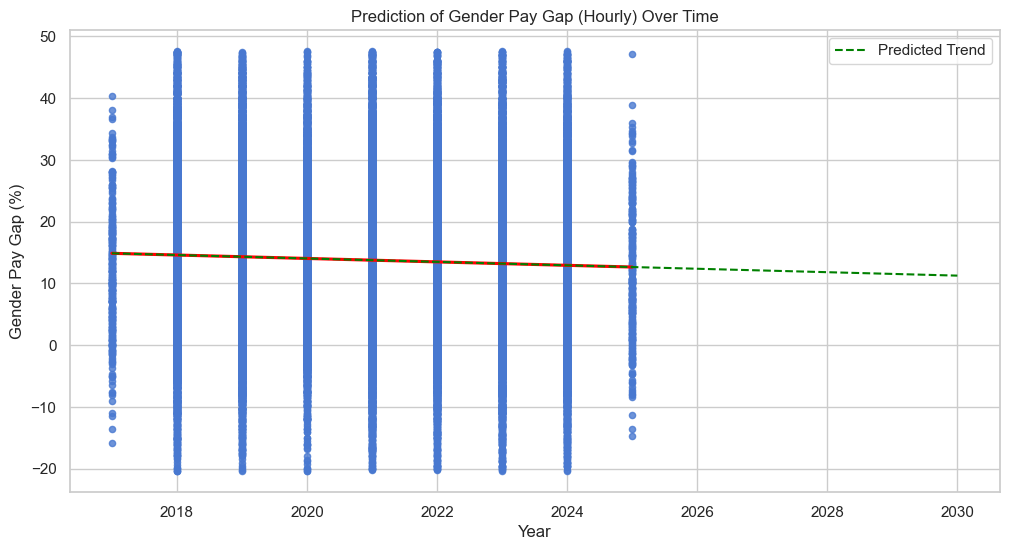

In [313]:
# Prepare data for regression (e.g., DiffMeanHourlyPercent over years)
X = df_clean[['year']]  # Feature: year
y = df_clean['DiffMeanHourlyPercent']  # Target: DiffMeanHourlyPercent (gender pay gap)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict the gender pay gap for the given years and future projections
years_future = np.array(range(df_clean['year'].min(), df_clean['year'].max() + 6)).reshape(-1, 1)  # Extend prediction for future 5 years
y_pred = model.predict(years_future)

# Plot the actual data and regression line
plt.figure(figsize=(12, 6))
sns.regplot(x='year', y='DiffMeanHourlyPercent', data=df_clean, scatter_kws={'s': 20}, line_kws={'color': 'red'}, ci=None)

# Plot the future prediction
plt.plot(years_future, y_pred, color='green', linestyle='--', label='Predicted Trend')

plt.title('Prediction of Gender Pay Gap (Hourly) Over Time')
plt.xlabel('Year')
plt.ylabel('Gender Pay Gap (%)')
plt.legend()
plt.show()